# **Machine Learning and Forecasting: Seminar 3**

Interpret the outputs of your answer where applicable.

In [96]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, roc_curve, auc 
import numpy as np
import matplotlib.pyplot as plt

# Part A: Questions with hints

##A.1. Difficulty Level: Simple to Intermediate

Q1: Read the dataset *Social_Network_Ads.csv* into Python. The detailed description of this dataset can be found on https://www.kaggle.com/datasets/akram24/social-network-ads. <font face="Calibri" size=1.5 color='#3543cd'> (Hint: use drive.mount() to read data into Google Colab from your Google drive:
`from google.colab import drive; drive.mount('/content/drive/')` then use `pd.read_csv` to read your csv file. For an example, you are referred to the seminar questions in Week 1.2
  <font>

In [25]:
Social_Network_Ads = pd.read_csv("Datasets/Social_Network_Ads.csv")

Q2. Show the names of all the features and the target in the dataset and the first 5 instances. Find the names of the categorical variables and list their distinct values, respectively. <font face="Calibri" size=1.5 color='#3543cd'> (Hint: use
`info()` to find which variables are categorical and `DataFrame[].unique()` to find distinct values.)
  <font>


In [26]:
Social_Network_Ads.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [27]:
Social_Network_Ads["Gender"].unique()

array(['Male', 'Female'], dtype=object)

Q3: Create dummy features for the categorical variable(s), then save these two dummy variables to the original dataset. <font face="Calibri" size=1.5 color='#3543cd'> (Hint: use
`encoded_values, unique_classes = pd.factorize(data['international plan'])` to create dummy values, which `unique_classes` is the dummy variable.
.)
  <font>

In [28]:
Social_Network_Ads["Gender_encoded"], unique_classes = pd.factorize(Social_Network_Ads["Gender"])

Q4: Check whether there is a multi-colinearity problem in the dataset created from Q3. <font face="Calibri" size=1.5 color='#3543cd'> (Hint: use
the relevant code written in the last seminar.)
  <font>

In [107]:
y = Social_Network_Ads["Purchased"]
X = Social_Network_Ads.drop(columns=["Purchased", "Gender"]) 

In [108]:
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns

# to calculate VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                          for i in range(len(X.columns))]

vif_data = vif_data.sort_values('VIF', ascending=False)

print(vif_data)

           feature        VIF
0          User ID  16.688407
1              Age  14.331499
2  EstimatedSalary   5.340526
3   Gender_encoded   2.057321


In [109]:
# Remove User ID
y = Social_Network_Ads["Purchased"]
X = Social_Network_Ads.drop(columns=["Purchased", "Gender", "User ID"]) 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [110]:
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns

# to calculate VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                          for i in range(len(X.columns))]

vif_data = vif_data.sort_values('VIF', ascending=False)

print(vif_data)

           feature       VIF
0              Age  5.160475
1  EstimatedSalary  4.642253
2   Gender_encoded  1.999529


Q5: Write Python code to split the dataset into two subsets: 80% of the dataset as the training dataset, and the rest as the test dataset. <font face="Calibri" size=1.5 color='#3543cd'> (Hint: This is the hold-out method we discussed. Use the library `from sklearn.model_selection import train_test_split
`, and 'X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)' to create the training dataset and the test dataset, respectively.)
  <font>

In [111]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Q6: Write Python code to fit a logistic regression model with 'Purchased' as the target, 'Age', 'EstimatedSalary', and 'Gender_encoded' as the features to the training dataset created in Q5, and output the model's coefficients, the p-value of the log likelihood ratio test, AIC and BIC values, respectively.  <font face="Calibri" size=1.5 color='#3543cd'> (Hint: The modelling part is similar to that we fitted a multiple regression model, by replacing `sm.ols` with `sm.Logit`.You are referred to https://www.statsmodels.org/stable/generated/statsmodels.discrete.discrete_model.LogitResults.html for details.You are referred to https://www.statsmodels.org/stable/generated/statsmodels.discrete.discrete_model.LogitResults.html for details.)
  <font>

In [127]:
#Suppose you want to add constant to independent variables X
X_train_data = sm.add_constant(X_train)

# Fit regression model
logreg = sm.Logit(y_train, X_train_data).fit() #where y is the dependent variable and X_train_data is the dependent variables

print(logreg.summary())
#to print out the values of AIC and BIC, respectively.
print("Model's AIC on the training dataset is:",logreg.aic)
print("Model's BIC on the training dataset is:",logreg.bic)

Optimization terminated successfully.
         Current function value: 0.372821
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:              Purchased   No. Observations:                  320
Model:                          Logit   Df Residuals:                      317
Method:                           MLE   Df Model:                            2
Date:                Mon, 26 Jan 2026   Pseudo R-squ.:                  0.4291
Time:                        13:43:19   Log-Likelihood:                -119.30
converged:                       True   LL-Null:                       -208.98
Covariance Type:            nonrobust   LLR p-value:                 1.133e-39
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             -11.4104      1.314     -8.686      0.000     -13.985      -8.836
Age           

In [113]:
# Perform backward selection
y = Social_Network_Ads["Purchased"]
X = Social_Network_Ads.drop(columns=["Purchased", "Gender", "User ID", "Gender_encoded"]) 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [128]:
#Suppose you want to add constant to independent variables X
X_train_data = sm.add_constant(X_train)

# Fit regression model
logreg = sm.Logit(y_train, X_train_data).fit() #where y is the dependent variable and X_train_data is the dependent variables

print(logreg.summary())
#to print out the values of AIC and BIC, respectively.
print("Model's AIC on the training dataset is:",logreg.aic)
print("Model's BIC on the training dataset is:",logreg.bic)

Optimization terminated successfully.
         Current function value: 0.372821
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:              Purchased   No. Observations:                  320
Model:                          Logit   Df Residuals:                      317
Method:                           MLE   Df Model:                            2
Date:                Mon, 26 Jan 2026   Pseudo R-squ.:                  0.4291
Time:                        13:43:31   Log-Likelihood:                -119.30
converged:                       True   LL-Null:                       -208.98
Covariance Type:            nonrobust   LLR p-value:                 1.133e-39
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             -11.4104      1.314     -8.686      0.000     -13.985      -8.836
Age           

Q7: For the model from Q6, write Python code to output the model's performance measures such as accuracy, precision, and AUC of the model on the test dataset.  <font face="Calibri" size=1.5 color='#3543cd'> (Hint: use `from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, roc_curve, auc
` to obtain the performance measures. You are referred to https://www.statsmodels.org/stable/generated/statsmodels.discrete.discrete_model.LogitResults.html for more information. You need to differentiate the predicted probabilities and the predicted labels. That is, you need to convert predicted probabilities to labels.)
  <font>

In [115]:
# 1. Prepare test data (DON'T forget the constant, same as training)
X_test_data = sm.add_constant(X_test, has_constant='add')

y_proba = logreg.predict(X_test_data)

In [116]:
#you need the following function to convert predicted probabilities to labels # converting probability to labels
def convert_prob_to_label(prob, cutoff = 0.5):
    label = None
    if prob > cutoff:
        label = 1
    else:
        label = 0
    return label
pred_labels = list(map(convert_prob_to_label, y_proba))#suppose Pred_on_Test is the predicted probabilites of your model on the test dataset
pred_labels = np.asarray(pred_labels)

In [117]:
confusion_matrix(y_test, pred_labels) 

array([[50,  2],
       [ 7, 21]])

In [118]:
precision_score(y_test, pred_labels) 

0.9130434782608695

In [119]:
accuracy_score(y_test, pred_labels) 

0.8875

In [120]:
roc_curve(y_test, pred_labels) 

(array([0.        , 0.03846154, 1.        ]),
 array([0.  , 0.75, 1.  ]),
 array([inf,  1.,  0.]))

In [121]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc(fpr, tpr)

0.9684065934065934

Q8: Write down the logistic regression model you fitted in Q5 (a model like $\log(\frac{\hat{p}(X)}{1-\hat{p}(X)})=\beta_0 +\beta_1 x_1+\dots+\beta_qx_q$) and interpret each coefficient in the model.

##A.2. Difficulty Level: Intermediate to Challenging

In [122]:
print(logreg.summary())

                           Logit Regression Results                           
Dep. Variable:              Purchased   No. Observations:                  320
Model:                          Logit   Df Residuals:                      317
Method:                           MLE   Df Model:                            2
Date:                Mon, 26 Jan 2026   Pseudo R-squ.:                  0.4291
Time:                        13:31:10   Log-Likelihood:                -119.30
converged:                       True   LL-Null:                       -208.98
Covariance Type:            nonrobust   LLR p-value:                 1.133e-39
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             -11.4104      1.314     -8.686      0.000     -13.985      -8.836
Age                 0.2079      0.026      7.968      0.000       0.157       0.259
EstimatedSalary  3.551e-05   5.7

LogOdds = -11.4 + *Age* x 0.2079 + *EstimatedSalary* x 3.55e-05

Q9. Write Python code to check whether  there are any influential points and outliers? List them if any.<font face="Calibri" size=1.5 color='#3543cd'> (Hint: You need to use a library `import numpy as np`, use `influence = logistic_model.get_influence()` to create instance of influence, obtain Cook's distance for each observation using `cooks = influence.cooks_distance`. The method used to answer this question is similar to the one we used in last week to detect anomalies.  
  <font>

In [123]:
influence = logreg.get_influence()
cooks_d = influence.cooks_distance[0]

# Identify influential observations
influencers = X_train.loc[cooks_d > (4 / len(X_train))]

influencers

,Age,EstimatedSalary
18,46,28000
16,47,25000
137,30,107000
17,45,26000
24,46,23000
218,46,96000
284,48,141000
168,29,148000
97,28,123000
23,45,22000


Q10: Check whether there is a linear relationship between $X_i$ and the target $y$ using the Box-Tidwell test. <font face="Calibri" size=1.5 color='#3543cd'> (Hint: use the Box-Tidwell test to test the linearity between $X_i log(X_i)$ and $y$.)
  <font>

In [124]:
X_transformed = X_train * np.log(X_train)

#Suppose you want to add constant to independent variables X
X_transformed_data = sm.add_constant(X_transformed)

# Fit regression model
logreg2 = sm.Logit(y_train, X_transformed_data).fit() #where y is the dependent variable and X_train_data is the dependent variables

print(logreg2.summary())

Optimization terminated successfully.
         Current function value: 0.369566
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:              Purchased   No. Observations:                  320
Model:                          Logit   Df Residuals:                      317
Method:                           MLE   Df Model:                            2
Date:                Mon, 26 Jan 2026   Pseudo R-squ.:                  0.4341
Time:                        13:31:12   Log-Likelihood:                -118.26
converged:                       True   LL-Null:                       -208.98
Covariance Type:            nonrobust   LLR p-value:                 3.998e-40
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -9.5500      1.086     -8.793      0.000     -11.679      -7.421
Age           

Passes as both variables are significant still.

Q11. Write Python code to draw a residual series plot, i.e., the deviance residuals of the logit values from the model fitted in Q10 against the index numbers of the observations.<font face="Calibri" size=1.5 color='#3543cd'> You need to use `logistic_model_2.resid_dev` to obtain the deviance residuals, assuming the logistic regression model you fitted in Q10 is named logistic_model_2.
  <font>

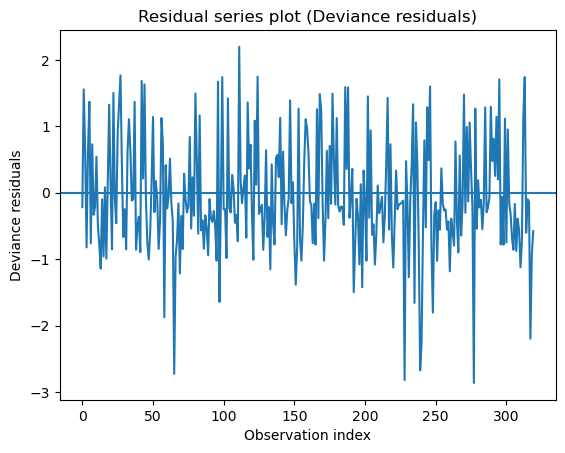

In [130]:
# 1. Obtain deviance residuals from the fitted logit model
deviance_residuals = logreg2.resid_dev

# 2. Create index numbers for observations
index = np.arange(len(deviance_residuals))

# 3. Plot residual series
plt.figure()
plt.plot(index, deviance_residuals
         #, marker='o', linestyle='None'
        )
plt.axhline(y=0)
plt.xlabel('Observation index')
plt.ylabel('Deviance residuals')
plt.title('Residual series plot (Deviance residuals)')
plt.show()

Q12. Based on the model fitted in Q10, write Python code to create scatter plots to visialise the features (i.e., Age and EstimatedSalary) vs the logit values, respectively. <font face="Calibri" size=1.5 color='#3543cd'> You need to use `logistic_model_2.predict(x_train)`---suppose x_train contains the training dataset with a constant---to predicted probabilities $\hat{p}(X)$, then use $\frac{\hat{p}(X)}{1-\hat{p}(X)}$ to obtain the logit values.
  <font>

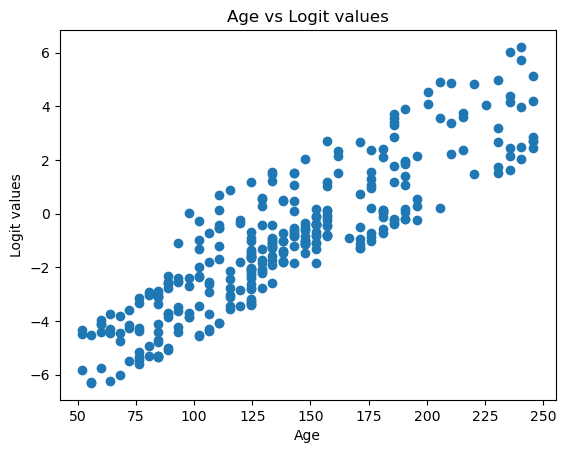

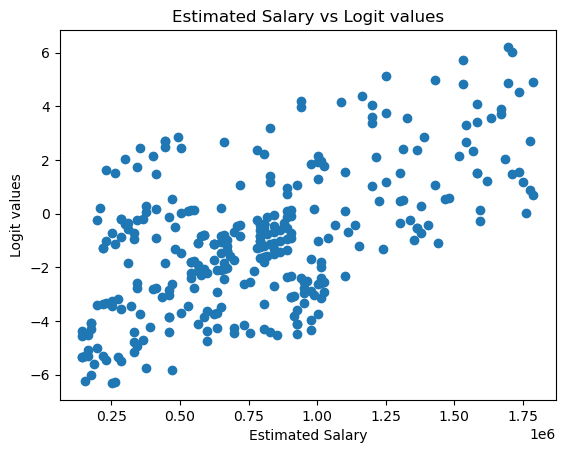

In [133]:
# 1. Predicted probabilities from the fitted logistic model
# x_train already includes a constant
p_hat = logreg2.predict(X_transformed_data)

# 2. Convert predicted probabilities to logit values
# logit(p) = log(p / (1 - p))
logit_values = np.log(p_hat / (1 - p_hat))

# 3. Scatter plot: Age vs logit values
plt.figure()
plt.scatter(X_transformed_data['Age'], logit_values)
plt.xlabel('Age')
plt.ylabel('Logit values')
plt.title('Age vs Logit values')
plt.show()

# 4. Scatter plot: EstimatedSalary vs logit values
plt.figure()
plt.scatter(X_transformed_data['EstimatedSalary'], logit_values)
plt.xlabel('Estimated Salary')
plt.ylabel('Logit values')
plt.title('Estimated Salary vs Logit values')
plt.show()


# Part B: Case study

This case study analyses the rate of customers lost during a specific period using the dataset, telecom_churn.csv, downloaded from https://archive.ics.uci.edu/dataset/563/iranian+churn+dataset. You need to fit a logistic regression model to it, and then perform model diagnostics to validate your model's assumptions.

Typically, we may answer the following questions.
- Q1: Read the dataset *telecom_churn.csv* into Python.
- Q2. Show the names of all the features and the target. Find whether there are any nominal variables. If any, create nummy variables to represent them, respectively.
- Q3. Write Python code to learn a logistic regression model with *churn* as the target. Using your common sense, manually check which features can be removed and which features should be included in the model.
- Q4. Write Python code to perform the forward feature selection method and the backward feature selection method, respectively. We used two feature selection functions in Seminar 2. To answer this question, you are encouraged to use a new function `SequentialFeatureSelector`, you can find its description on https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SequentialFeatureSelector.html.
- Q5. Write Python code to check if there exists multicolinearity among features. If any, cure it.
- Q6. Write Python code to check whether  there are any influential points and outliers? List them if any.
- Q7. Write Python code to produce performance measures such as AIC, BIC, Accruacy, Precision, and AUC.
- Q8. Write down the final logistic regression model. Interpret its coefficients, explain its accuracy, precision, and AUC, respectively.

In [136]:
# 1 Read in data
telecom_churn = pd.read_csv("Datasets/telecom_churn.csv")
telecom_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

In [138]:
telecom_churn["state"].unique()

array(['KS', 'OH', 'NJ', 'OK', 'AL', 'MA', 'MO', 'LA', 'WV', 'IN', 'RI',
       'IA', 'MT', 'NY', 'ID', 'VT', 'VA', 'TX', 'FL', 'CO', 'AZ', 'SC',
       'NE', 'WY', 'HI', 'IL', 'NH', 'GA', 'AK', 'MD', 'AR', 'WI', 'OR',
       'MI', 'DE', 'UT', 'CA', 'MN', 'SD', 'NC', 'WA', 'NM', 'NV', 'DC',
       'KY', 'ME', 'MS', 'TN', 'PA', 'CT', 'ND'], dtype=object)

In [139]:
telecom_churn["international plan"].unique()

array(['no', 'yes'], dtype=object)

In [141]:
telecom_churn["voice mail plan"].unique()

array(['yes', 'no'], dtype=object)

In [142]:
telecom_churn["phone number"].unique()

array(['382-4657', '371-7191', '358-1921', ..., '328-8230', '364-6381',
       '400-4344'], shape=(3333,), dtype=object)

In [143]:
# 2 One hot encode variables
telecom_churn = pd.get_dummies(telecom_churn, columns=["international plan", "voice mail plan", "state"], drop_first=True)

In [144]:
telecom_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 70 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   account length          3333 non-null   int64  
 1   area code               3333 non-null   int64  
 2   phone number            3333 non-null   object 
 3   number vmail messages   3333 non-null   int64  
 4   total day minutes       3333 non-null   float64
 5   total day calls         3333 non-null   int64  
 6   total day charge        3333 non-null   float64
 7   total eve minutes       3333 non-null   float64
 8   total eve calls         3333 non-null   int64  
 9   total eve charge        3333 non-null   float64
 10  total night minutes     3333 non-null   float64
 11  total night calls       3333 non-null   int64  
 12  total night charge      3333 non-null   float64
 13  total intl minutes      3333 non-null   float64
 14  total intl calls        3333 non-null   

In [218]:
# 3 Fit a model
# Split and select variables manually
y = telecom_churn["churn"]
X = telecom_churn.drop(columns=["churn", "phone number", "area code"]) 

# Instantiate logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SequentialFeatureSelector
logreg = LogisticRegression()

# Backwards selection
sfs = SequentialFeatureSelector(logreg, direction='forward', tol = 0.0005)
sfs.fit(X, y)
selected_features = sfs.get_feature_names_out()

In [219]:
selected_features

array(['total night minutes', 'total intl calls',
       'customer service calls'], dtype=object)

In [220]:
# 4 Check for multi colinearity
X = X[selected_features].astype(int)
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns

# to calculate VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                          for i in range(len(X.columns))]

vif_data = vif_data.sort_values('VIF', ascending=False)

print(vif_data)

                  feature       VIF
0     total night minutes  4.451468
1        total intl calls  3.607203
2  customer service calls  2.237350


In [221]:
# Drop total night minutes as too correlated
X = X.drop(columns=["total night minutes"]) 

In [222]:
# 5 Fit new model
# split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Instantiate logistic regression
X_const = sm.add_constant(X_train)  # IMPORTANT
logit_model = sm.Logit(y_train, X_const).fit()

print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.388892
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                  churn   No. Observations:                 2666
Model:                          Logit   Df Residuals:                     2663
Method:                           MLE   Df Model:                            2
Date:                Mon, 26 Jan 2026   Pseudo R-squ.:                 0.05352
Time:                        16:07:23   Log-Likelihood:                -1036.8
converged:                       True   LL-Null:                       -1095.4
Covariance Type:            nonrobust   LLR p-value:                 3.444e-26
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -2.1856      0.144    -15.213      0.000      -2.467      

Threshold for Cook Distance = 0.0012001200120012002
Proportion of data points that are highly influential = 10.2%


,cooks_d,std_resid
41,0.026946,5.070013
2001,0.020473,4.010162
2947,0.016645,3.862938
514,0.015184,4.532030
2029,0.009548,4.205429


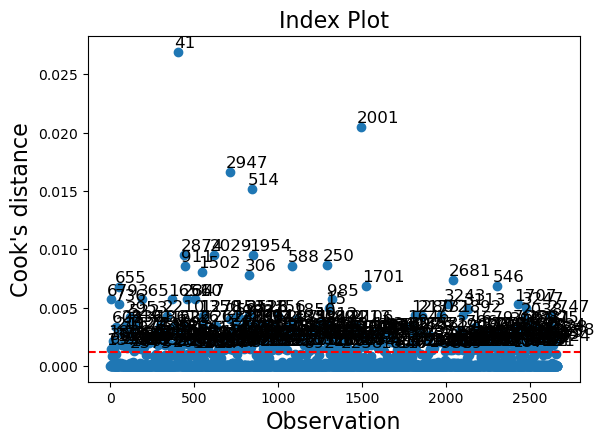

In [223]:
# 6 Check for outliers and influencial points
######################################
#####to calculate Cook's distance#####
######################################

from scipy import stats

# Get influence measures: to iniliaze
influence = logit_model.get_influence()

# Obtain summary df of influence measures
summ_df = influence.summary_frame()

# Filter summary df to Cook distance
diagnosis_df = summ_df.loc[:,['cooks_d']]

# Append absolute standardized residual values
diagnosis_df['std_resid'] = stats.zscore(logit_model.resid_pearson)
diagnosis_df['std_resid'] = diagnosis_df.loc[:,'std_resid'].apply(lambda x: np.abs(x))

# Sort by Cook's Distance
diagnosis_df.sort_values("cooks_d", ascending=False)
diagnosis_df.head()

# Set Cook's distance threshold
cook_threshold = 4 / len(X)
print(f"Threshold for Cook Distance = {cook_threshold}")

import matplotlib.pyplot as plt
# Plot influence measures (Cook's distance)
fig = influence.plot_index(y_var="cooks", threshold=cook_threshold)
plt.axhline(y = cook_threshold, ls="--", color='red')
fig.tight_layout(pad=2) #those instances above the read line are influential instances.

# Find number of observations that exceed Cook's distance threshold
influentials = diagnosis_df[diagnosis_df['cooks_d'] > cook_threshold]
prop_influentials = round(100*(len(influentials) / len(X)),1)
print(f'Proportion of data points that are highly influential = {prop_influentials}%')


# Find number of observations which are BOTH outlier (std dev > 3) and highly influential
extreme = diagnosis_df[(diagnosis_df['cooks_d'] > cook_threshold) &
                       (diagnosis_df['std_resid'] > 3)]
prop_extreme = round(100*(len(extreme) / len(X)),1)

# Display top 5 most influential instances and outliers
extreme.sort_values("cooks_d", ascending=False).head()


In [224]:
# 7 get the summary stats of the logistic regression
x_test = sm.add_constant(X_test) #
Pred_on_Test = logit_model.predict(x_test) #When using the hold-out method, we measure the performance of a modelling method on the test dataset, rather than on the training dataset

# converting probability to labels
def convert_prob_to_label(prob, cutoff = 0.5):
    label = None
    if prob > cutoff:
        label = 1
    else:
        label = 0
    return label

pred_labels = list(map(convert_prob_to_label, Pred_on_Test))

import numpy as np
pred_labels = np.asarray(pred_labels)

#to initilise false positive rate(fpr), true positive rate(tpr), and AUC, respectively
fpr = dict()
tpr = dict()
roc_auc = dict()

# importing Libraries
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, roc_curve, auc

# Confusion Matrix
cm = confusion_matrix(y_test, pred_labels)
# Accuracy
accuracy = accuracy_score(y_test, pred_labels)
# Precision
precision = precision_score(y_test, pred_labels)
# ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, Pred_on_Test)
roc_auc = auc(fpr, tpr)

print("Confusion Matrix:")
print(cm)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("ROC AUC:", roc_auc)

Confusion Matrix:
[[566   0]
 [100   1]]
Accuracy: 0.8500749625187406
Precision: 1.0
ROC AUC: 0.6097418045691495



## Summary
- Understand the assumptions of logistic regression models, those assumptions include: (1) the autocorelationship among the residuals; (2) the independence (i.e., multi-colinearity) between the independent features; (3) linearity; and (4) sufficiently large sample size;
- Understand the $k$-fold cross validation method and the hold-out method;
- Understand how you convert a categorical variable to dummy variables; and
- Improve the performance of a logistic regression model by checking the presence of outliers, influences, or leverages.

## A brief introduction to Python libraries: `statsmodels` and `scikit-learn`
- There are two core Python libraries for multiple linear regression and logistic regression. They are `statsmodels` and `scikit-learn` and can be used to fit models, analyse data, and generate predictions;
- `statemodels` offers rich statistical summaries, which makes it an ideal tool for explanation and teaching, whereas `scikit-learn` is more suitable for prediction;
- If you use `statsmodels`, you need `import statsmodels.api as sm` to import the library, and then use `sm.OLS(y, x)` and `sm.Logit(y, x)` to fit a multiple linear regression and a logistic regression model, respectively;
- If you use `scikit-learn`, you need `from sklearn.linear_model import LinearRegression` and `from sklearn.linear_model import LogisticRegression` to import the libraries for fitting a multiple linear regression model and a multiple logistic regression model, respectively. You need then use `linear_model().fit(X,y)` and `LogisticRegression().fit(X, y)` to fit the dataset with X as the set of features and y as the target.
- With `statsmodels` (you need `import statsmodels.api as sm` to import the library), you can also use `sm.GLM(y, X, family=sm.families.Gaussian())` for multiple linear regression and `sm.GLM(y, X, family=sm.families.Binomial()).fit()` for logistic regression modelling.

## Suggested reading for the Next Lecture
- To review/google classification modelling methods: $k$-nearest neighbours, decision trees, and random forests.
- To review the following sections/chapter in the book ***Raschka, S., & Mirjalili, V. (2019). Python machine learning: Machine learning and deep learning with Python, scikit-learn, and TensorFlow 2. Packt publishing ltd***:
   1. Chapter 3;
   1. The first two sections in Chapter 7 (i.e., section "learning with ensembles" and Section "Bagging");
   1. Sections "Dealing with nonlinear relationships using random forests" and "Using regularised methods for regression" in Chapter 10.
- Alternatively, you can review the following sections/chapter in the book ***An Introduction to Statistical Learning: with Applications in Python (Springer Texts in Statistics)***
   1. Section 4.7.6: $K$-Nearest Neighbours in Chapter 4;
   1. Section 6.2: "Shrinkage Methods", and
   1. Chapter 8: Tree-based methods.

